<centre> <h1>Movie Recommendation Systems</h1> </centre>

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)

### Load Data Sets

In [2]:
from src.data_loader import load_movies, load_ratings

movies = load_movies()
ratings = load_ratings()

## Movies Data Overview

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
movies.shape

(27278, 3)

In [5]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
dtypes: int64(1), str(2)
memory usage: 639.5 KB


In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

We can observe that column title contains title of the movie and year of its release let's seperate and create a new column year for the release year of the movie.

In [7]:
# Extarct release year
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)$')

#Remove year from title
movies['title'] = movies['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

#Clean Extra spaces
movies['title'] = movies['title'].str.strip()

#convert year to integer
movies['year'] = movies['year'].astype('Int64')

In [8]:
movies.head()

,movieId,title,genres,year
0,1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji,Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men,Comedy|Romance,1995
3,4,Waiting to Exhale,Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II,Comedy,1995


In [9]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  27278 non-null  int64
 1   title    27278 non-null  str  
 2   genres   27278 non-null  str  
 3   year     27049 non-null  Int64
dtypes: Int64(1), int64(1), str(2)
memory usage: 879.2 KB


In [10]:
movies.isnull().sum()

movieId      0
title        0
genres       0
year       229
dtype: int64

## Genre Distribution

In [11]:
#split genres
movies['genre_list'] = movies['genres'].str.split('|')

#Flatten all genres
from itertools import chain

all_genres = list(chain.from_iterable(movies['genre_list']))

#Count genre frequency
import pandas as pd

genre_counts = pd.Series(all_genres).value_counts()

genre_counts

Drama                 13344
Comedy                 8374
Thriller               4178
Romance                4127
Action                 3520
Crime                  2939
Horror                 2611
Documentary            2471
Adventure              2329
Sci-Fi                 1743
Mystery                1514
Fantasy                1412
War                    1194
Children               1139
Musical                1036
Animation              1027
Western                 676
Film-Noir               330
(no genres listed)      246
IMAX                    196
Name: count, dtype: int64

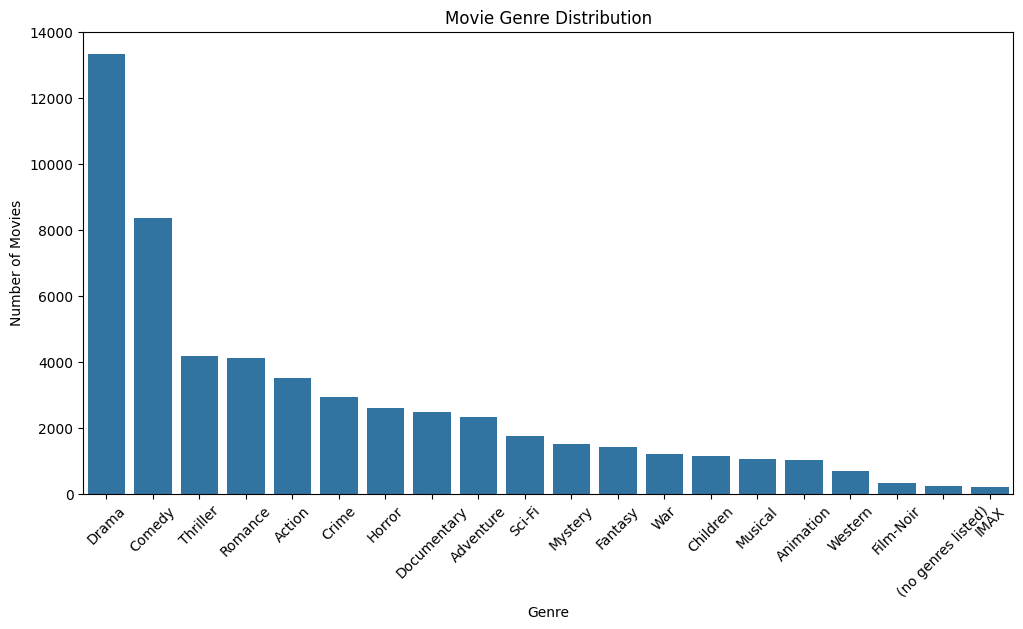

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_counts.index,
    y=genre_counts.values
)

plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)

plt.show()

### Generes Distribution Analysis

- We can observe Drama is the most common genre, followed by Comedy and Thriller, indicating that these genres dominate the dataset. Genres such as Romance, Action, and Crime also appear frequently, suggesting a strong presence of popular mainstream categories.
- On the other hand, genres like Film-Noir, Western, and IMAX have significantly fewer movies, making them relatively rare in the dataset.
- This distribution highlights an imbalance in genre representation, which may influence recommendation models that rely on genre similarity.
- Popular genres may dominate recommendations, while less frequent genres might have fewer similar movies available.

# Ratings Dataset Overview

In [13]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


In [14]:
ratings.shape

(20000263, 4)

In [15]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB


In [16]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [17]:
ratings.describe()

,userId,movieId,rating,timestamp
count,2.000026e+07,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00,1.100918e+09
std,4.003863e+04,1.978948e+04,1.051989e+00,1.621694e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,3.439500e+04,9.020000e+02,3.000000e+00,9.667977e+08
50%,6.914100e+04,2.167000e+03,3.500000e+00,1.103556e+09
75%,1.036370e+05,4.770000e+03,4.000000e+00,1.225642e+09
max,1.384930e+05,1.312620e+05,5.000000e+00,1.427784e+09


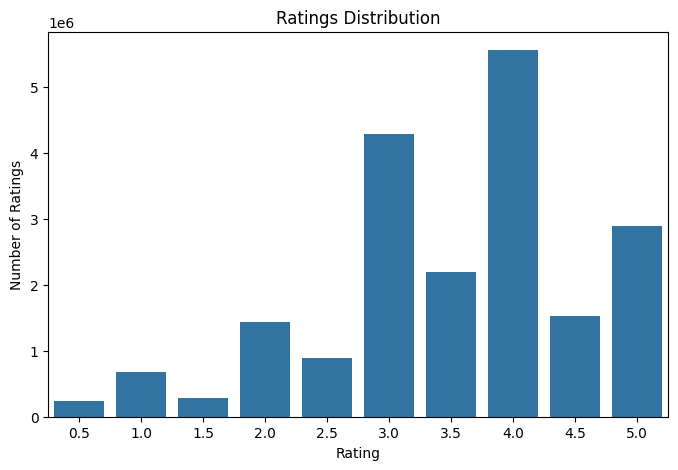

In [18]:
rating_counts = ratings['rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values
)

plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

### Ratings Distribution Analysis

- The bar plot shows the distribution of ratings given by users. 
- Most ratings fall between **3.0 and 4.0**, indicating that users generally give relatively positive ratings to movies. 
- Lower ratings occur less frequently, suggesting that users tend to rate movies they like more often than movies they dislike.


# Merge Movies data and Ratings data

In [19]:
from src.data_loader import merge_datasets,save_dataset
df = merge_datasets(movies, ratings)

df.head()

,userId,movieId,rating,timestamp,title,genres,year,genre_list
0,1,2,3.5,1112486027,Jumanji,Adventure|Children|Fantasy,1995,"[Adventure, Children, Fantasy]"
1,1,29,3.5,1112484676,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,1995,"[Adventure, Drama, Fantasy, Mystery, Sci-Fi]"
2,1,32,3.5,1112484819,Twelve Monkeys (a.k.a. 12 Monkeys),Mystery|Sci-Fi|Thriller,1995,"[Mystery, Sci-Fi, Thriller]"
3,1,47,3.5,1112484727,Seven (a.k.a. Se7en),Mystery|Thriller,1995,"[Mystery, Thriller]"
4,1,50,3.5,1112484580,"Usual Suspects, The",Crime|Mystery|Thriller,1995,"[Crime, Mystery, Thriller]"


In [20]:
df.shape

(20000263, 8)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 8 columns):
 #   Column      Dtype  
---  ------      -----  
 0   userId      int64  
 1   movieId     int64  
 2   rating      float64
 3   timestamp   int64  
 4   title       str    
 5   genres      str    
 6   year        Int64  
 7   genre_list  object 
dtypes: Int64(1), float64(1), int64(3), object(1), str(2)
memory usage: 1.2+ GB


In [22]:
df.isnull().sum()

userId           0
movieId          0
rating           0
timestamp        0
title            0
genres           0
year          1452
genre_list       0
dtype: int64

In [23]:
#save the merged data to DataSets
save_dataset(df, "../DataSets/merged_movies_ratings.csv")